In [ ]:
from torchvision.datasets import CIFAR10
import numpy as np

train_dataset = CIFAR10(
    root="../data",
    train=True,
    download=False
)

images = np.array(train_dataset.data)
labels = np.array(train_dataset.targets)

print(images.shape)
print(labels.shape)

(50000, 32, 32, 3)
(50000,)


In [2]:
import random

noisy_labels = labels.copy()

noise_ratio = 0.10

num_noisy = int(len(labels) * noise_ratio)

indices = np.random.choice(
    len(labels),
    num_noisy,
    replace=False
)

for idx in indices:

    current_label = noisy_labels[idx]

    possible_labels = list(range(10))
    possible_labels.remove(current_label)

    noisy_labels[idx] = random.choice(
        possible_labels
    )

print("Noisy labels created")

Noisy labels created


In [3]:
changed = np.sum(labels != noisy_labels)

print(changed)

5000


In [4]:
np.save(
    "../outputs/noisy_indices.npy",
    indices
)

In [5]:
print(train_dataset.classes)

['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [6]:
cat_label = 3
dog_label = 5

cat_indices = np.where(
    noisy_labels == cat_label
)[0]

dog_indices = np.where(
    noisy_labels == dog_label
)[0]

keep_cat = np.random.choice(
    cat_indices,
    500,
    replace=False
)

keep_dog = np.random.choice(
    dog_indices,
    500,
    replace=False
)

In [7]:
other_indices = np.where(
    (noisy_labels != cat_label) &
    (noisy_labels != dog_label)
)[0]

final_indices = np.concatenate([
    keep_cat,
    keep_dog,
    other_indices
])

In [8]:
imbalanced_images = images[final_indices]
imbalanced_labels = noisy_labels[final_indices]

In [12]:
from collections import Counter

Counter(imbalanced_labels)

Counter({np.int64(8): 5079,
         np.int64(0): 5010,
         np.int64(6): 5000,
         np.int64(9): 4997,
         np.int64(7): 4996,
         np.int64(4): 4995,
         np.int64(1): 4950,
         np.int64(2): 4940,
         np.int64(3): 500,
         np.int64(5): 500})

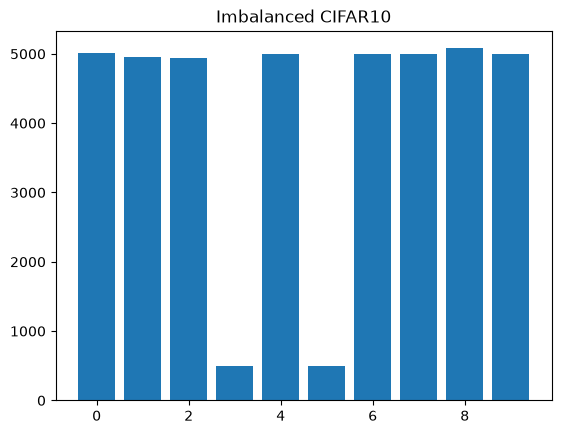

In [13]:
import matplotlib.pyplot as plt

counts = Counter(
    imbalanced_labels
)

plt.bar(
    counts.keys(),
    counts.values()
)

plt.title(
    "Imbalanced CIFAR10"
)

plt.show()

In [19]:
from torchvision.datasets import SVHN

svhn = SVHN(
    root="../data",
    split="train",
    download=True
)

In [20]:
ood_count = 200

ood_indices = np.random.choice(
    len(svhn),
    ood_count,
    replace=False
)

In [21]:
ood_images = []

for idx in ood_indices:
    img, _ = svhn[idx]
    ood_images.append(
        np.array(img)
    )

ood_images = np.array(
    ood_images
)

In [22]:
ood_labels = np.full(
    ood_count,
    -1
)

In [23]:
final_images = np.concatenate([
    imbalanced_images,
    ood_images
])

final_labels = np.concatenate([
    imbalanced_labels,
    ood_labels
])

In [24]:
print(final_images.shape)
print(final_labels.shape)

(41167, 32, 32, 3)
(41167,)


In [26]:
np.save(
    "../data/processed/images.npy",
    final_images
)

np.save(
    "../data/processed/labels.npy",
    final_labels
)

In [27]:
np.save(
    "../outputs/ood_indices.npy",
    np.arange(
        len(final_images)-ood_count,
        len(final_images)
    )
)

# Dataset Corruption Summary

Label Noise Injected:
10%

Minority Classes:
Cat, Dog

Samples Remaining:
500 each

OOD Samples Added:
200 SVHN Images

Purpose:
Create a realistic benchmark for
data auditing, OOD detection,
and synthetic augmentation.